In [2]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pickle
import shap
import warnings 

warnings.filterwarnings("ignore")

In [3]:
# Exporting and cleaning the dataset
dfug = pd.read_csv("data/uganda_dataset.csv")

# Filling missing values
dfug.fillna(dfug.median(numeric_only=True), inplace=True)

dfug

,company,year,bankrupt,Attr27,Attr11,Attr7,Attr34,Attr22,Attr25,Attr13,...,Attr42,Attr6,Attr35,Attr59,Attr30,Attr43,Attr4,Attr48,Attr24,Attr39
0,MTN Uganda Ltd,2024,0,3.993233,0.614978,0.248249,0.262494,0.248249,0.251446,0.970087,...,0.365451,0.251446,0.248249,1.058202,1.047004,10.051567,0.797376,0.354415,0.552810,0.365451
1,MTN Uganda Ltd,2025,0,4.381439,0.614982,0.258867,0.247434,0.258867,0.224681,0.979166,...,0.384861,0.224681,0.258867,1.167532,1.038800,9.163294,0.785988,0.361579,0.555900,0.384861
2,EABL PLC,2024,0,3.037919,0.497748,0.200391,0.269975,0.200391,0.282912,0.498246,...,0.200578,0.135186,0.200391,1.398635,0.610629,102.602085,1.150370,0.266388,0.431785,0.200578
3,EABL PLC,2025,0,4.193753,0.458311,0.192013,0.278684,0.192013,0.310520,0.483283,...,0.195440,0.152163,0.192013,1.064369,0.590542,124.289320,1.110971,0.254297,0.412526,0.195440
4,Equity Group Holdings PLC,2024,0,0.986456,0.100735,0.033658,0.064341,0.033658,0.135752,0.706121,...,0.334129,0.129021,0.033658,0.000000,6.673391,1644.880273,0.747128,0.038175,0.066614,0.334129
5,Equity Group Holdings PLC,2025,0,1.972526,0.101567,0.046735,0.058729,0.046735,0.164494,0.815563,...,0.460142,0.141308,0.046735,0.000000,6.271730,1608.971592,0.773195,0.051696,0.077874,0.460142
6,KCB Group PLC,2024,0,1.159461,0.095562,0.041137,0.049823,0.041137,0.142569,0.680708,...,0.430473,0.123867,0.041137,0.000000,8.345177,1922.188520,0.656193,0.046104,0.060083,0.430473
7,KCB Group PLC,2025,0,1.464007,0.094634,0.040566,0.047869,0.040566,0.157107,0.748394,...,0.428664,0.135141,0.040566,0.000000,7.767637,2062.432591,0.761880,0.044465,0.066925,0.428664
8,Absa Bank Uganda Ltd,2024,0,1.864713,0.127142,0.043002,0.099945,0.043002,0.130527,0.829482,...,0.338219,0.102072,0.043002,0.000000,5.815698,1053.795591,0.557710,0.044382,0.104081,0.338219
9,Absa Bank Uganda Ltd,2025,0,1.755689,0.117948,0.041295,0.088896,0.041295,0.116397,0.810230,...,0.350113,0.111244,0.041295,0.000000,6.361285,941.602323,0.482731,0.042433,0.094427,0.350113


Text(0, 0.5, 'Frequency')

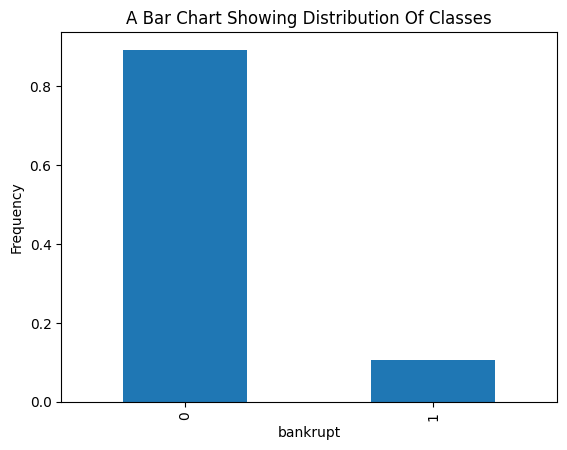

In [4]:
# A Plot showing Distribution of classes
dfug["bankrupt"].value_counts(normalize=True).plot(kind="bar")
plt.title("A Bar Chart Showing Distribution Of Classes")
plt.ylabel("Frequency")

In [8]:
# Preparing features and target variable

X_ug = dfug.drop(columns=['company', 'year', 'bankrupt'])
correct_order = [
    'Attr11', 'Attr27', 'Attr34', 'Attr26', 'Attr6', 'Attr39', 'Attr7',
    'Attr22', 'Attr4', 'Attr21', 'Attr13', 'Attr42', 'Attr48',
    'Attr30', 'Attr35', 'Attr25', 'Attr59', 'Attr24', 'Attr43',
    'Attr38'
]

X_ug = X_ug[correct_order]
y_ug = dfug['bankrupt']

In [5]:
# Loading trained Gradient
with open("models/model_xgb.pkl", "rb") as f:
    model = pickle.load(f)

In [7]:
model.feature_names_in_

array(['Attr11', 'Attr27', 'Attr34', 'Attr26', 'Attr6', 'Attr39', 'Attr7',
       'Attr22', 'Attr4', 'Attr21', 'Attr13', 'Attr42', 'Attr48',
       'Attr30', 'Attr35', 'Attr25', 'Attr59', 'Attr24', 'Attr43',
       'Attr38'], dtype='<U6')

In [9]:
predictions= model.predict(X_ug)

probabilities = model.predict_proba(X_ug)

In [10]:
model.classes_

array([0, 1, 2, 3, 4, 5])

In [11]:
model.named_steps

{'xgbclassifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=7, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=100, n_jobs=None,
               num_parallel_tree=None, ...)}

In [12]:
dfug['Prediction'] = predictions

dfug['Probability'] = probabilities[:,1]

***Using SHAP for feature Importance and Recommendation system***

In [14]:
model = model.named_steps['xgbclassifier']
explainer = shap.Explainer(model.predict, X_ug)
#explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_ug)

PermutationExplainer explainer: 29it [00:12,  2.18it/s]                        


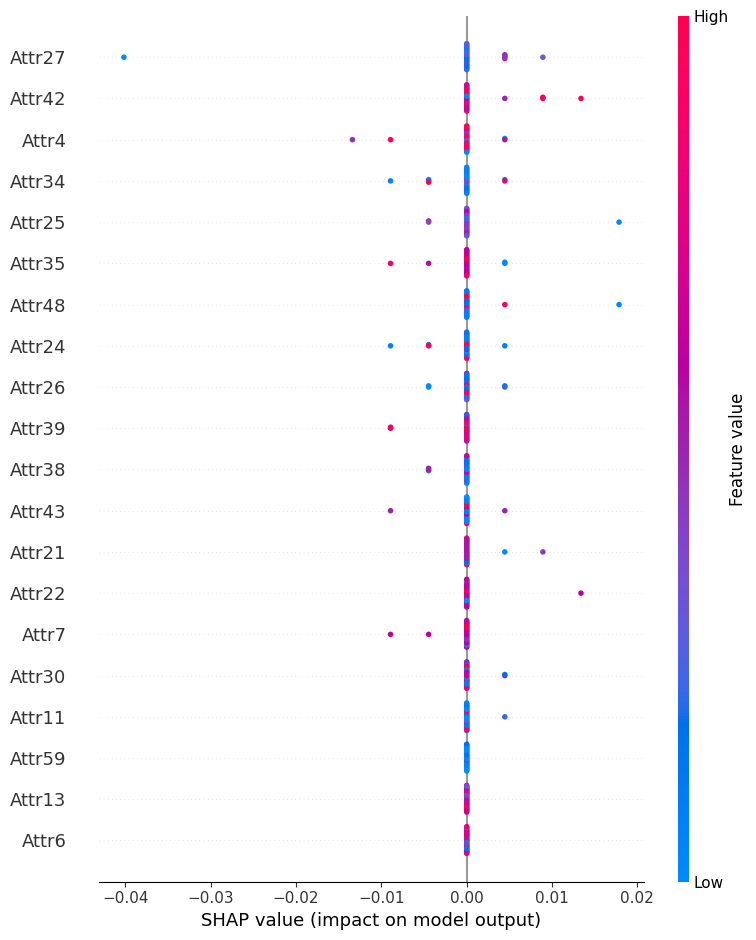

In [15]:
shap.summary_plot(
    shap_values,
    X_ug
)

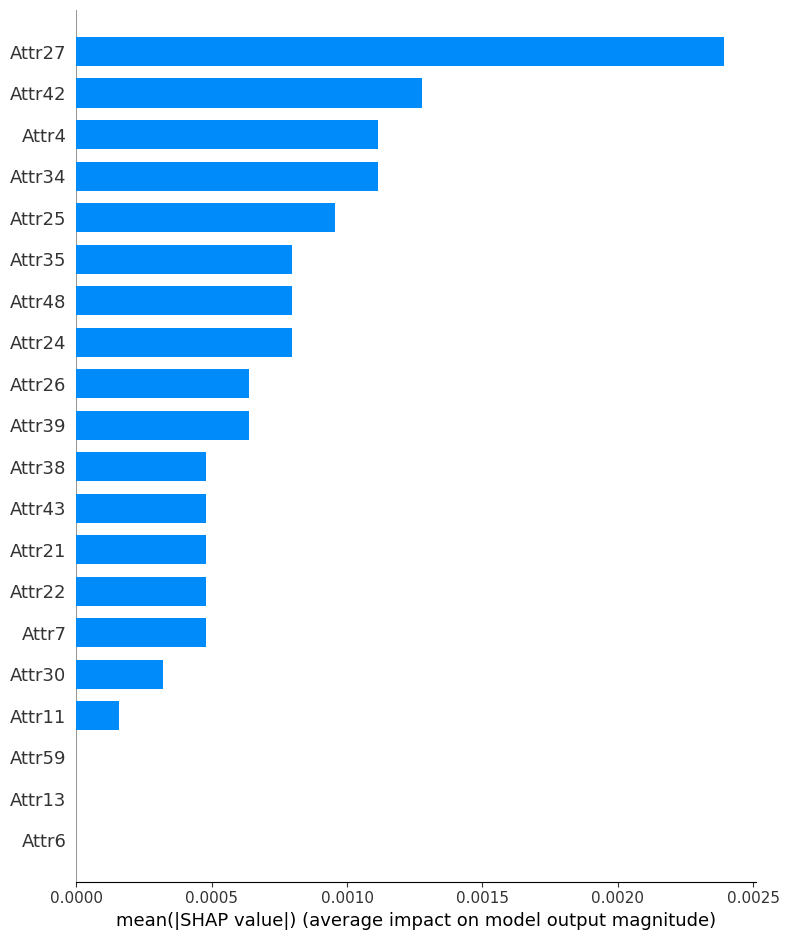

In [16]:
shap.summary_plot(
    shap_values,
    X_ug,
    plot_type="bar"
)

In [17]:
sample_index=0
X_ug.iloc[sample_index]

Attr11     0.614978
Attr27     3.993233
Attr34     0.262494
Attr26     0.327423
Attr6      0.251446
Attr39     0.365451
Attr7      0.248249
Attr22     0.248249
Attr4      0.797376
Attr21     1.105303
Attr13     0.970087
Attr42     0.365451
Attr48     0.354415
Attr30     1.047004
Attr35     0.248249
Attr25     0.251446
Attr59     1.058202
Attr24     0.552810
Attr43    10.051567
Attr38     0.527392
Name: 0, dtype: float64

In [18]:
sample_shap = shap_values[sample_index]

shap_df = pd.DataFrame({
    "Feature": X_ug.columns,
    "Value": X_ug.iloc[sample_index].values,
    "SHAP": sample_shap
})

shap_df.sort_values("SHAP", ascending=False)

,Feature,Value,SHAP
12,Attr48,0.354415,0.004464
0,Attr11,0.614978,0.000000
2,Attr34,0.262494,0.000000
1,Attr27,3.993233,0.000000
3,Attr26,0.327423,0.000000
4,Attr6,0.251446,0.000000
6,Attr7,0.248249,0.000000
5,Attr39,0.365451,0.000000
8,Attr4,0.797376,0.000000
9,Attr21,1.105303,0.000000


In [53]:

print("Top Positive Contributors")
print(shap_df.sort_values("SHAP", ascending=False).head(5))

print("\nTop Negative Contributors")
print(shap_df.sort_values("SHAP").head(5))

Top Positive Contributors
   Feature     Value      SHAP
18  Attr35 -1.222332  0.171875
16  Attr46  0.288181  0.104167
14  Attr25 -2.663659  0.067708
15  Attr24  3.215895  0.057292
8   Attr57 -0.822939  0.052083

Top Negative Contributors
   Feature          Value      SHAP
4   Attr55 -353989.000000 -0.213542
3    Attr6      -4.566515 -0.104167
13  Attr40       0.238296 -0.088542
19  Attr27      -4.089457 -0.046875
1   Attr12       0.200850 -0.036458


In [19]:
top_risks = shap_df.sort_values("SHAP", ascending=False).head(5)

In [20]:
prediction = model.predict(X_ug.iloc[[sample_index]])
print(prediction)

[0]


In [54]:
recommendation_map = {

    'Attr35':
        'Improve profitability by increasing revenue and reducing operational expenses.',

    'Attr46':
        'Improve liquidity by increasing current assets or reducing short-term liabilities.',

    'Attr25':
        'Strengthen retained earnings through profit retention and prudent dividend policies.',

    'Attr24':
        'Improve long-term profitability and asset utilization efficiency.',

    'Attr57':
        'Improve working capital management and cash flow planning.',

    'Attr55':
        'Increase working capital and maintain adequate cash reserves.',

    'Attr40':
        'Strengthen liquid assets and cash reserves.',

    'Attr27':
        'Reduce financial expenses and debt servicing costs.',

    'Attr12':
        'Improve short-term debt coverage through higher profits.'
}

In [55]:
top_risks = shap_df.sort_values(
    "SHAP",
    ascending=False
).head(5)

for feature in top_risks["Feature"]:

    if feature in recommendation_map:

        print(f"{feature}")
        print(recommendation_map[feature])
        print()

Attr35
Improve profitability by increasing revenue and reducing operational expenses.

Attr46
Improve liquidity by increasing current assets or reducing short-term liabilities.

Attr25
Strengthen retained earnings through profit retention and prudent dividend policies.

Attr24
Improve long-term profitability and asset utilization efficiency.

Attr57
Improve working capital management and cash flow planning.

